In [1]:
import sklearn
import pandas as pd
import numpy as np
import xgboost as xgb
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from xgboost import XGBRegressor


In [2]:
from xgboost import XGBRegressor

In [3]:
df = pd.read_csv("data_rdkit.csv")

In [4]:
df.shape

(12358, 166)

In [5]:
df['pIC50'].describe()

count    12358.000000
mean         6.322479
std          1.458666
min          1.000000
25%          5.200659
50%          6.301030
75%          7.259637
max         11.198288
Name: pIC50, dtype: float64

In [6]:
gen = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fp(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return np.zeros(2048, dtype=np.uint8)
    fp = gen.GetFingerprintAsNumPy(mol)  # возвращает numpy array напрямую
    return fp

# Генерируем матрицу
fp_matrix = np.stack(df['Smiles'].apply(smiles_to_fp).values)

# Добавляем в датафрейм
fp_cols = [f'fp_{i}' for i in range(2048)]
fp_df = pd.DataFrame(fp_matrix, columns=fp_cols, index=df.index)

df = pd.concat([df, fp_df], axis=1)

In [7]:
target = "pIC50"
drop_cols = "Smiles"
y = df[target]
X = df.drop(columns=[drop_cols] + [target])
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    
)

In [8]:
dtrain = xgb.DMatrix(X_train, label=y_train)

dtest  = xgb.DMatrix(X_test) 

dtrain = xgb.DMatrix(X_train, label=y_train)

In [9]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
    }

    model = XGBRegressor(**params)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    return -scores.mean()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Лучшие параметры:", study.best_params)
print("Лучший RMSE:", study.best_value)

# Обучаем финальную модель с лучшими параметрами
best_model = XGBRegressor(**study.best_params, random_state=42)
best_model.fit(X_train, y_train)

preds = best_model.predict(X_test)

/home/mark/miniforge3/envs/ml1/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-21 11:45:40,385] A new study created in memory with name: no-name-b5aa3d8e-3c6b-461c-b226-bab970be1257
Best trial: 0. Best value: 0.737672:   5%|▌         | 1/20 [00:13<04:12, 13.30s/it]

[I 2026-03-21 11:45:53,685] Trial 0 finished with value: 0.7376715578427179 and parameters: {'n_estimators': 334, 'max_depth': 7, 'learning_rate': 0.19131977531500977, 'subsample': 0.7999047051194197, 'colsample_bytree': 0.7037654710848109}. Best is trial 0 with value: 0.7376715578427179.


Best trial: 1. Best value: 0.711319:  10%|█         | 2/20 [00:47<07:37, 25.42s/it]

[I 2026-03-21 11:46:27,588] Trial 1 finished with value: 0.7113192875782884 and parameters: {'n_estimators': 457, 'max_depth': 10, 'learning_rate': 0.050641369241026586, 'subsample': 0.712134980089634, 'colsample_bytree': 0.8818816174336326}. Best is trial 1 with value: 0.7113192875782884.


Best trial: 1. Best value: 0.711319:  15%|█▌        | 3/20 [01:19<08:06, 28.61s/it]

...

[I 2026-03-21 11:52:35,021] Trial 17 finished with value: 0.7175930630842434 and parameters: {'n_estimators': 468, 'max_depth': 8, 'learning_rate': 0.03305346886941798, 'subsample': 0.8214632554438014, 'colsample_bytree': 0.76910542455906}. Best is trial 1 with value: 0.7113192875782884.


Best trial: 1. Best value: 0.711319:  95%|█████████▌| 19/20 [07:20<00:23, 23.47s/it]

[I 2026-03-21 11:53:01,210] Trial 18 finished with value: 0.8230442018397248 and parameters: {'n_estimators': 189, 'max_depth': 10, 'learning_rate': 0.010990093715865568, 'subsample': 0.7841905553446875, 'colsample_bytree': 0.7780275097910357}. Best is trial 1 with value: 0.7113192875782884.


Best trial: 1. Best value: 0.711319: 100%|██████████| 20/20 [07:33<00:00, 22.67s/it]


[I 2026-03-21 11:53:13,860] Trial 19 finished with value: 0.7171211800944356 and parameters: {'n_estimators': 251, 'max_depth': 8, 'learning_rate': 0.11937241419329048, 'subsample': 0.6761198740905991, 'colsample_bytree': 0.739352529907011}. Best is trial 1 with value: 0.7113192875782884.
Лучшие параметры: {'n_estimators': 457, 'max_depth': 10, 'learning_rate': 0.050641369241026586, 'subsample': 0.712134980089634, 'colsample_bytree': 0.8818816174336326}
Лучший RMSE: 0.7113192875782884


In [13]:
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
)

rmse = root_mean_squared_error(y_test, preds)
mae  = mean_absolute_error(y_test, preds)
r2   = r2_score(y_test, preds)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

RMSE: 0.6634
MAE:  0.4644
R²:   0.7885


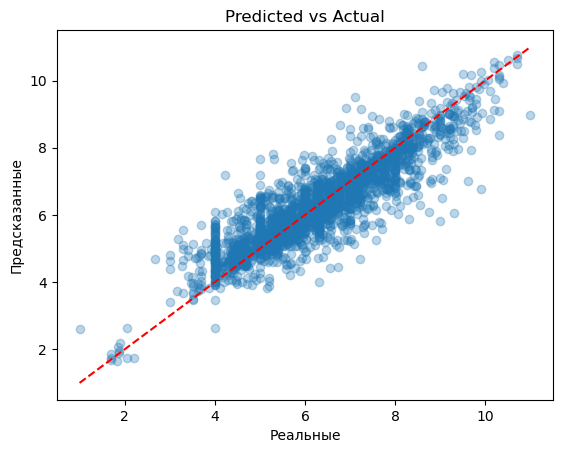

In [14]:
import matplotlib.pyplot as plt

plt.scatter(y_test, preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--")
plt.xlabel("Реальные")
plt.ylabel("Предсказанные")
plt.title("Predicted vs Actual")
plt.show()

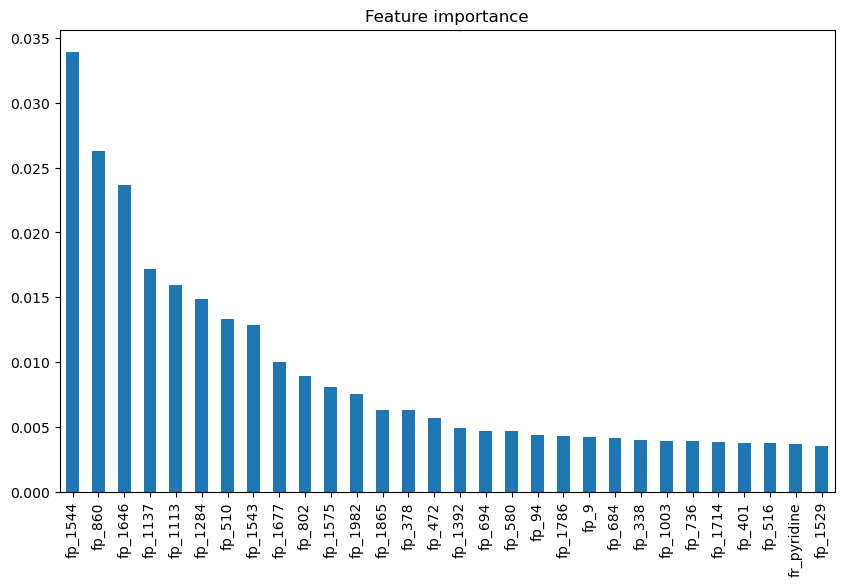

In [15]:
import pandas as pd

feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
plt.figure(figsize=[10,6])
feat_imp.head(30).plot(kind="bar")
plt.title("Feature importance")
plt.show()

In [16]:
best_model.save_model("xgb_model.ubj")

# Загрузить потом
loaded_model = XGBRegressor()
loaded_model.load_model("xgb_model.ubj")

In [17]:
import joblib

joblib.dump(best_model, "xgb_ampc.pkl")

['xgb_ampc.pkl']